# Taxi trips dataset: predicting tips

In [ ]:
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MPLCONFIGDIR = ROOT / "experiments" / ".matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection
import tqdm.auto as tqdm

PLOTS_DIR = ROOT / "experiments" / "generated_plots" / "taxi_extended_topk_minimized"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

from lazyfca.lazyfca import LazyFCA
from utils.estimate_quality import estimate_quality

In [2]:
import pandas
import sklearn.compose
import sklearn.model_selection
import sklearn.preprocessing

numeric = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tolls_amount',
    'improvement_surcharge',
    'congestion_surcharge',
    'Airport_fee',
    'cbd_congestion_fee'
]

categorical = [
    'VendorID',
    'RatecodeID',
    'store_and_fwd_flag',
    # 'PULocationID',
    # 'DOLocationID',
    'payment_type',
]

target = 'tip_amount'

data = pandas.read_parquet("../datasets/yellow_tripdata_2026-01.parquet")
data = data[~data['passenger_count'].isna()]
data = pandas.concat([
    data[data['tip_amount'] != 0][:15000],
    data[data['tip_amount'] == 0][:15000]
])

y = (data['tip_amount'] != 0).to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    data, y, test_size = 0.1, stratify = y, random_state = 42
)

ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool', sparse_output = False), categorical)
    ]
)
X_train = pandas.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())
X_train

,numeric__passenger_count,numeric__trip_distance,numeric__fare_amount,numeric__extra,numeric__mta_tax,numeric__tolls_amount,numeric__improvement_surcharge,numeric__congestion_surcharge,numeric__Airport_fee,numeric__cbd_congestion_fee,...,categorical__RatecodeID_3.0,categorical__RatecodeID_4.0,categorical__RatecodeID_5.0,categorical__RatecodeID_99.0,categorical__store_and_fwd_flag_N,categorical__store_and_fwd_flag_Y,categorical__payment_type_1,categorical__payment_type_2,categorical__payment_type_3,categorical__payment_type_4
0,1.0,2.53,12.1,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,3.0,6.85,31.7,0.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.00,3.0,1.00,0.5,0.0,1.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,3.0,0.76,7.9,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.00,30.0,0.75,0.0,0.0,1.0,0.0,0.0,0.75,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26995,4.0,1.60,12.8,3.25,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
26996,1.0,1.05,8.6,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
26997,2.0,1.88,15.6,0.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
26998,2.0,2.72,19.1,1.00,0.5,0.0,1.0,2.5,0.0,0.75,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [3]:
import catboost
classifier = catboost.CatBoostClassifier(iterations = 100)
classifier.fit(X_train, y_train)
y_pred = classifier.predict_proba(X_test)
estimate_quality(y_pred, y_test)

Learning rate set to 0.347637
0:	learn: 0.3418634	total: 86.4ms	remaining: 8.55s
1:	learn: 0.2515245	total: 93ms	remaining: 4.56s
2:	learn: 0.2311585	total: 99.7ms	remaining: 3.22s
3:	learn: 0.2188878	total: 106ms	remaining: 2.53s
4:	learn: 0.2139275	total: 112ms	remaining: 2.13s
5:	learn: 0.2101088	total: 118ms	remaining: 1.85s
6:	learn: 0.2080504	total: 124ms	remaining: 1.65s
7:	learn: 0.2071496	total: 130ms	remaining: 1.49s
8:	learn: 0.2059942	total: 136ms	remaining: 1.37s
9:	learn: 0.2037746	total: 141ms	remaining: 1.27s
10:	learn: 0.2026101	total: 147ms	remaining: 1.19s
11:	learn: 0.2014910	total: 153ms	remaining: 1.12s
12:	learn: 0.2009311	total: 159ms	remaining: 1.06s
13:	learn: 0.2003277	total: 164ms	remaining: 1.01s
14:	learn: 0.1999611	total: 170ms	remaining: 964ms
15:	learn: 0.1998309	total: 176ms	remaining: 923ms
16:	learn: 0.1992423	total: 182ms	remaining: 888ms
17:	learn: 0.1989249	total: 187ms	remaining: 853ms
18:	learn: 0.1986172	total: 194ms	remaining: 826ms
19:	learn:

{'Accuracy': 0.9246666666666666,
 'Precision': 0.8922413793103449,
 'Recall': 0.966,
 'AUC-ROC': 0.9569435555555557,
 'F1-score': 0.9276568501920615,
 'True Positive': 1449,
 'True Negative': 1325,
 'False Positive': 175,
 'False Negative': 51,
 'True Negative Rate (Specificity)': 0.8833333333333333,
 'Negative Predictive Value': 0.9629360465116279,
 'False Positive Rate': 0.11666666666666667,
 'False Discovery Rate': 0.10775862068965517}

## Baseline Threshold Params

`LazyFCA.Params(...)` is the threshold object used by LazyFCA.

Important detail:
- this object reuses the same dataclass as the metrics themselves,
- but when passed into `LazyFCA(...)`, its values are interpreted as lower/upper bounds for filtering classifiers.

Example:
- `supporters_covered=1` means keep only classifiers covering at least 1 supporter,
- `supporter_opposer_ratio=1.0` means keep only classifiers whose supporter/opposer ratio is at least 1.0.

Here we keep the same baseline thresholds as in the original rice notebook. They serve only as a permissive pre-filter before ranking.

In [4]:
baseline_classifier = LazyFCA(minimize_policy=LazyFCA.MinimizePolicy.BEFORE_FILTER)
baseline_classifier.fit(X_train, y_train)

LazyFCA
  Status       : fitted
  Dataset      : 27000 samples (pos=13500, neg=13500)
  Features     : 0 binary, 25 numeric

  Filtering thresholds
  ------------------------------------
  pos_params    : (none)
  neg_params    : (none)
  pos_weight    : 1.0

  Ranking & top-k
  ------------------------------------
  pos_rank_by   : —
  neg_rank_by   : —
  rank_by       : —
  pos_top_k     : —
  neg_top_k     : —
  top_k         : —
  minimize_policy: MinimizePolicy.BEFORE_FILTER

In [5]:
baseline_explanations = baseline_classifier.explain(X_test)
print(len(baseline_explanations))

baseline_y_pred = baseline_classifier.classify_explanations(baseline_explanations, trust = True)
baseline_metrics = estimate_quality(baseline_y_pred, y_test)
baseline_metrics

100%|██████████| 3000/3000 [36:50<00:00,  1.36it/s]


3000


{'Accuracy': 0.5,
 'Precision': 0.0,
 'Recall': 0.0,
 'AUC-ROC': 0.38127999999999995,
 'F1-score': 0.0,
 'True Positive': 0,
 'True Negative': 1500,
 'False Positive': 0,
 'False Negative': 1500,
 'True Negative Rate (Specificity)': 1.0,
 'Negative Predictive Value': 0.5,
 'False Positive Rate': 0.0,
 'False Discovery Rate': 0}

## Precompute Explanations Once

Efficiency idea:
- explanations are the expensive part,
- threshold sweeps or top-k sweeps should not recompute them,
- we precompute them once using the baseline threshold filter,
- every metric/k experiment reuses those explanations.

In [7]:
explanations = baseline_explanations
len(explanations)

3000

In [8]:
available_metrics = [
    "supporters_covered",
    "opposers_covered",
    "supporter_opposer_ratio",
    "support",
    "error_rate",
    "precision",
    "lift",
    "wracc",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "interval_tightness",
    "description_volume",
    "simplicity_prior",
    "query_binary_similarity",
    "query_numeric_similarity",
    "query_similarity",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "robustness",
    "delta_stability",
]

available_metrics

['supporters_covered',
 'opposers_covered',
 'supporter_opposer_ratio',
 'support',
 'error_rate',
 'precision',
 'lift',
 'wracc',
 'balanced_precision_proxy',
 'youdens_j',
 'matthews_correlation',
 'information_gain',
 'gini_gain',
 'log_odds_ratio',
 'chi_squared',
 'g_test',
 'interval_tightness',
 'description_volume',
 'simplicity_prior',
 'query_binary_similarity',
 'query_numeric_similarity',
 'query_similarity',
 'query_weighted_precision',
 'query_weighted_wracc',
 'stability',
 'robustness',
 'delta_stability']

## Efficient Pooled Top-k Evaluation

For each explanation and each metric:
1. put positive and negative classifiers in one pooled list,
2. score them by the chosen metric,
3. sort descending,
4. compute cumulative counts of positive and negative classifiers,
5. reuse those cumulative counts for all values of k.

This makes each metric experiment much faster than recomputing `predict()` for every k.

In [9]:
MINIMIZED_METRICS = {"opposers_covered", "error_rate", "description_volume"}

def metric_score(classifier, metric_name):
    value = classifier.get_metrics().get_metric(metric_name)
    return -value if metric_name in MINIMIZED_METRICS else value

def build_metric_cache(explanations, metric_name):
    cache = []
    for explanation in tqdm.tqdm(explanations, desc=f"Caching {metric_name}"):
        pooled = [
            *[(metric_score(clf, metric_name), 1) for clf in explanation.positive_classifiers],
            *[(metric_score(clf, metric_name), 0) for clf in explanation.negative_classifiers],
        ]

        if not pooled:
            cache.append({
                "total": 0,
                "cum_pos": np.array([], dtype=np.int32),
                "cum_neg": np.array([], dtype=np.int32),
            })
            continue

        pooled.sort(key=lambda item: item[0], reverse=True)
        labels = np.array([label for _, label in pooled], dtype=np.int32)
        cum_pos = np.cumsum(labels)
        cum_neg = np.cumsum(1 - labels)

        cache.append({
            "total": len(labels),
            "cum_pos": cum_pos,
            "cum_neg": cum_neg,
        })

    return cache

def predict_from_metric_cache(metric_cache, k, pos_weight=1.0):
    y_pred = np.zeros((len(metric_cache), 2), dtype=np.float64)

    for i, item in enumerate(metric_cache):
        total_available = item["total"]
        if total_available == 0 or k <= 0:
            y_pred[i] = [0.5, 0.5]
            continue

        take = min(k, total_available)
        pos_count = int(item["cum_pos"][take - 1])
        neg_count = int(item["cum_neg"][take - 1])

        weighted_pos = pos_weight * pos_count
        total = weighted_pos + neg_count
        if total == 0:
            y_pred[i] = [0.5, 0.5]
        else:
            y_pred[i] = [neg_count / total, weighted_pos / total]

    return y_pred

def evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    metric_cache = build_metric_cache(explanations, metric_name)
    rows = []

    for k in tqdm.tqdm(k_values, desc=f"Evaluating {metric_name}"):
        y_pred = predict_from_metric_cache(metric_cache, k, pos_weight=pos_weight)
        metrics = estimate_quality(y_pred, y_true)
        avg_kept = float(np.mean([min(k, item["total"]) for item in metric_cache]))
        rows.append({
            "k": int(k),
            "F1-score": metrics["F1-score"],
            "Accuracy": metrics["Accuracy"],
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "AUC-ROC": metrics["AUC-ROC"],
            "Average classifiers kept": avg_kept,
        })

    return pd.DataFrame(rows)

def plot_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_test, pos_weight=1.0):
    results = evaluate_metric_topk(metric_name, k_values, explanations=explanations, y_true=y_true, pos_weight=pos_weight)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    plot_path = PLOTS_DIR / f"{metric_name}_topk_f1.png"

    plt.figure(figsize=(12, 6))
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=2)
    plt.axhline(baseline_metrics["F1-score"], color="red", linestyle="--", label="Baseline threshold-only")
    plt.scatter([best_row["k"]], [best_row["F1-score"]], color="green", s=80, zorder=3, label="Best Top-k")
    plt.xlabel("Top-k")
    plt.ylabel("F1-score")
    plt.title(f"F1-score vs pooled Top-k for metric: {metric_name}")
    plt.xlim(results["k"].max(), results["k"].min())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")
    print(f"Best k for {metric_name}: {int(best_row['k'])}")
    print(f"Best F1-score: {best_row['F1-score']:.6f}")
    print(f"Average classifiers kept: {best_row['Average classifiers kept']:.2f}")

    return results

In [10]:
# Build a top-heavy k-grid from the actual number of pooled classifiers.
# It always includes 1 and the maximum available number of classifiers.
# The grid is intentionally dense near the full classifier count.
max_total_classifiers = max(
    len(explanation.positive_classifiers) + len(explanation.negative_classifiers)
    for explanation in explanations
)

def build_top_heavy_k_grid(max_k, dense_tail=80, mid_points=50, low_points=30):
    if max_k <= 1:
        return np.array([1], dtype=int)

    values = {1, max_k}

    tail_start = max(1, max_k - dense_tail + 1)
    values.update(range(tail_start, max_k + 1))

    t = np.linspace(0.0, 1.0, mid_points)
    mid = np.rint(1 + (max_k - 1) * (t ** 2)).astype(int)
    values.update(mid.tolist())

    low = np.geomspace(1, max_k, low_points)
    low = np.rint(low).astype(int)
    values.update(low.tolist())

    return np.array(sorted(values, reverse=True), dtype=int)

k_values = build_top_heavy_k_grid(max_total_classifiers, dense_tail=80, mid_points=50, low_points=30)
print("Max pooled classifiers:", max_total_classifiers)
print("Number of k values:", len(k_values))
print("First 25 k values:", k_values[:25])
print("Last 25 k values:", k_values[-25:])
k_values

Max pooled classifiers: 2461
Number of k values: 153
First 25 k values: [2461 2460 2459 2458 2457 2456 2455 2454 2453 2452 2451 2450 2449 2448
 2447 2446 2445 2444 2443 2442 2441 2440 2439 2438 2437]
Last 25 k values: [125 103  97  84  74  67  57  51  43  38  33  27  25  19  17  15  11  10
   9   7   5   4   3   2   1]


array([2461, 2460, 2459, 2458, 2457, 2456, 2455, 2454, 2453, 2452, 2451,
       2450, 2449, 2448, 2447, 2446, 2445, 2444, 2443, 2442, 2441, 2440,
       2439, 2438, 2437, 2436, 2435, 2434, 2433, 2432, 2431, 2430, 2429,
       2428, 2427, 2426, 2425, 2424, 2423, 2422, 2421, 2420, 2419, 2418,
       2417, 2416, 2415, 2414, 2413, 2412, 2411, 2410, 2409, 2408, 2407,
       2406, 2405, 2404, 2403, 2402, 2401, 2400, 2399, 2398, 2397, 2396,
       2395, 2394, 2393, 2392, 2391, 2390, 2389, 2388, 2387, 2386, 2385,
       2384, 2383, 2382, 2362, 2264, 2169, 2076, 1985, 1895, 1880, 1808,
       1723, 1640, 1559, 1480, 1436, 1404, 1329, 1256, 1185, 1117, 1097,
       1050,  986,  923,  863,  838,  804,  748,  694,  641,  640,  591,
        543,  497,  489,  453,  411,  374,  371,  333,  297,  286,  263,
        232,  218,  202,  174,  167,  149,  127,  125,  103,   97,   84,
         74,   67,   57,   51,   43,   38,   33,   27,   25,   19,   17,
         15,   11,   10,    9,    7,    5,    4,   

## Example: WRAcc

Caching wracc:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/153 [00:00<?, ?it/s]

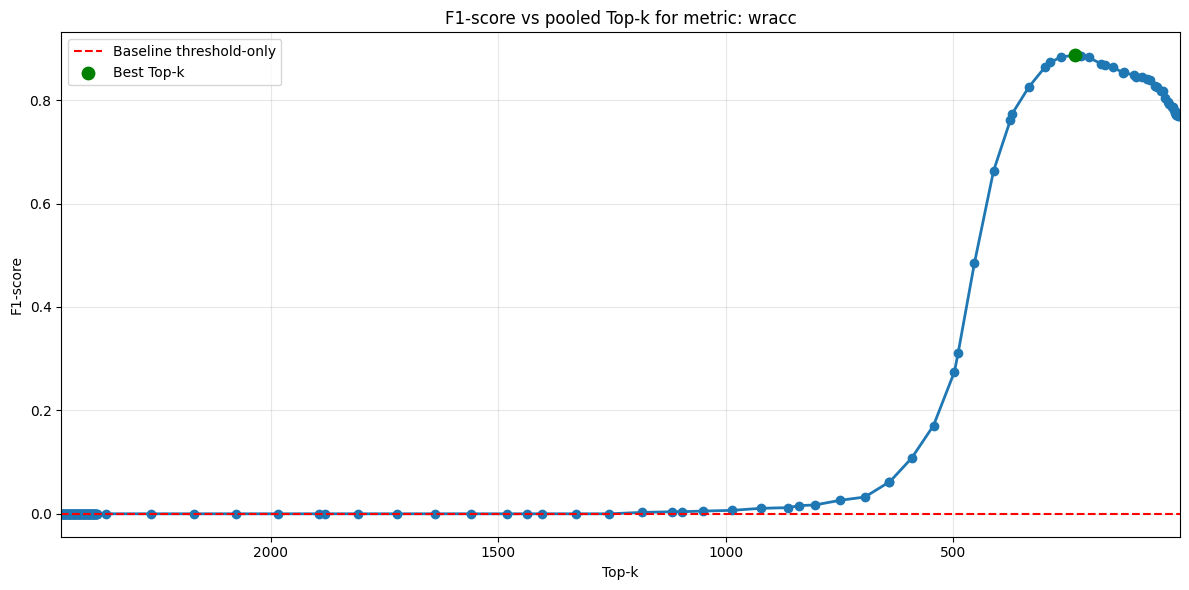

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\wracc_topk_f1.png
Best k for wracc: 232
Best F1-score: 0.886662
Average classifiers kept: 232.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,2461,0.000000,0.500000,0.000000,0.000,0.381280,884.417000
1,2460,0.000000,0.500000,0.000000,0.000,0.381280,884.416667
2,2459,0.000000,0.500000,0.000000,0.000,0.381280,884.416333
3,2458,0.000000,0.500000,0.000000,0.000,0.381280,884.416000
4,2457,0.000000,0.500000,0.000000,0.000,0.381281,884.415667
...,...,...,...,...,...,...,...
148,5,0.770021,0.701333,0.626043,1.000,0.727055,5.000000
149,4,0.772997,0.706333,0.629987,1.000,0.722100,4.000000
150,3,0.768836,0.699333,0.624480,1.000,0.716131,3.000000
151,2,0.773643,0.708000,0.631646,0.998,0.708386,2.000000


In [11]:
wracc_results = plot_metric_topk("wracc", k_values)
wracc_results

## Run Any Metric

Examples:
- `plot_metric_topk("precision", k_values)`
- `plot_metric_topk("balanced_precision_proxy", k_values)`
- `plot_metric_topk("information_gain", k_values)`
- `plot_metric_topk("query_weighted_precision", k_values)`
- `plot_metric_topk("stability", k_values)`

Caching information_gain:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating information_gain:   0%|          | 0/153 [00:00<?, ?it/s]

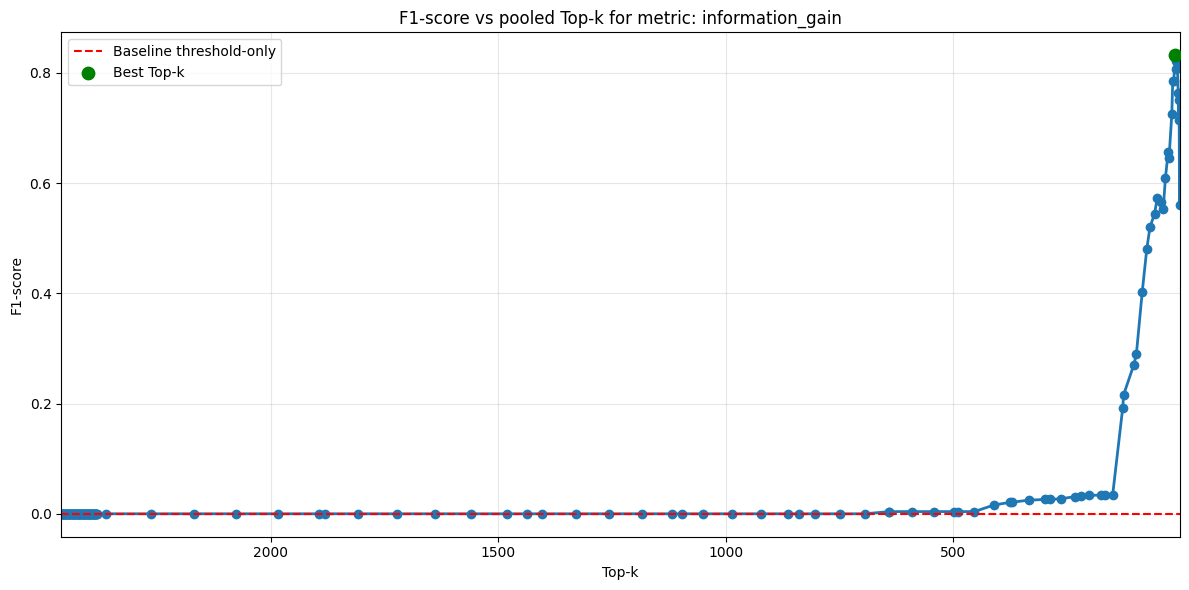

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\information_gain_topk_f1.png
Best k for information_gain: 11
Best F1-score: 0.832091
Average classifiers kept: 11.00


,k,F1-score,Accuracy,Precision,Recall,AUC-ROC,Average classifiers kept
0,2461,0.000000,0.500000,0.000000,0.000000,0.381280,884.417000
1,2460,0.000000,0.500000,0.000000,0.000000,0.381280,884.416667
2,2459,0.000000,0.500000,0.000000,0.000000,0.381280,884.416333
3,2458,0.000000,0.500000,0.000000,0.000000,0.381280,884.416000
4,2457,0.000000,0.500000,0.000000,0.000000,0.381281,884.415667
...,...,...,...,...,...,...,...
148,5,0.762926,0.749333,0.723684,0.806667,0.799551,5.000000
149,4,0.714528,0.719000,0.726084,0.703333,0.792197,4.000000
150,3,0.751742,0.738667,0.715923,0.791333,0.772884,3.000000
151,2,0.560095,0.630333,0.691479,0.470667,0.741152,2.000000


In [12]:
metric_name = "information_gain"
results = plot_metric_topk(metric_name, k_values)
results

## Batch Run Over Several Metrics

This cell is optional. It can take time, but it is still much cheaper than recomputing explanations for every metric and every k.

In [13]:
metrics_to_try = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

summary_rows = []
for metric_name in metrics_to_try:
    results = evaluate_metric_topk(metric_name, k_values)
    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]
    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": best_row["F1-score"],
        "avg_classifiers_kept": best_row["Average classifiers kept"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df

Caching wracc:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/153 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/153 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/153 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/153 [00:00<?, ?it/s]

,metric,best_k,best_f1,avg_classifiers_kept
1,lift,174,0.911984,174.0
8,query_weighted_precision,3,0.911828,3.0
3,matthews_correlation,232,0.891799,232.0
9,query_weighted_wracc,232,0.887850,232.0
0,wracc,232,0.886662,232.0
2,balanced_precision_proxy,232,0.886662,232.0
4,information_gain,11,0.832091,11.0
7,g_test,11,0.832091,11.0
5,gini_gain,11,0.794178,11.0
6,chi_squared,11,0.794178,11.0



=== wracc ===


Caching wracc:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/153 [00:00<?, ?it/s]

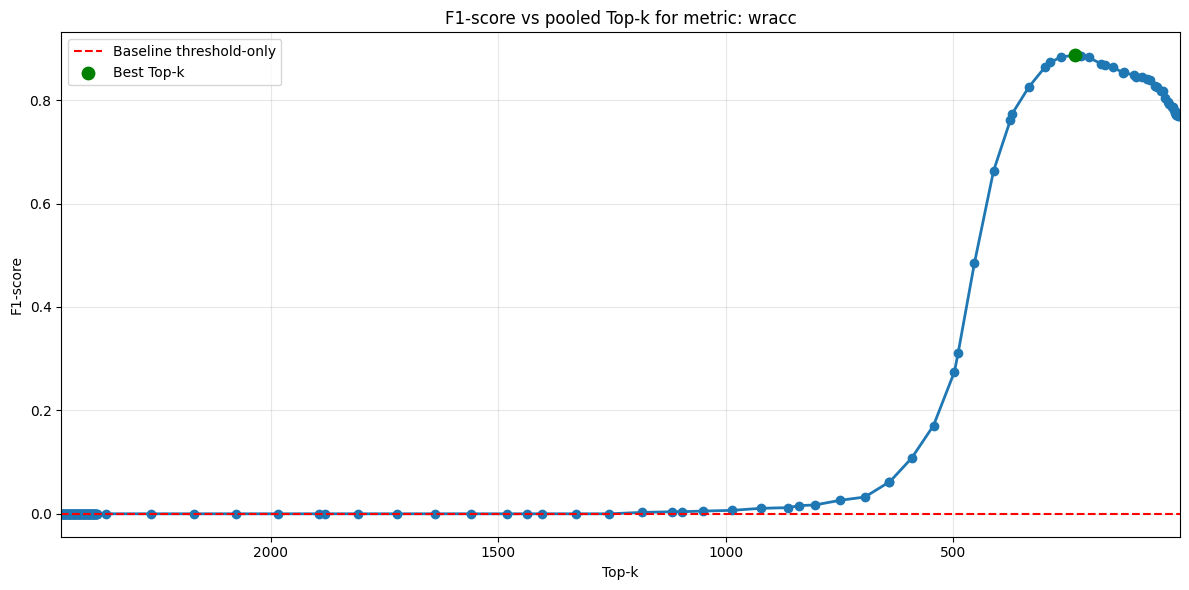

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\wracc_topk_f1.png
Best k for wracc: 232
Best F1-score: 0.886662
Average classifiers kept: 232.00

=== lift ===


Caching lift:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/153 [00:00<?, ?it/s]

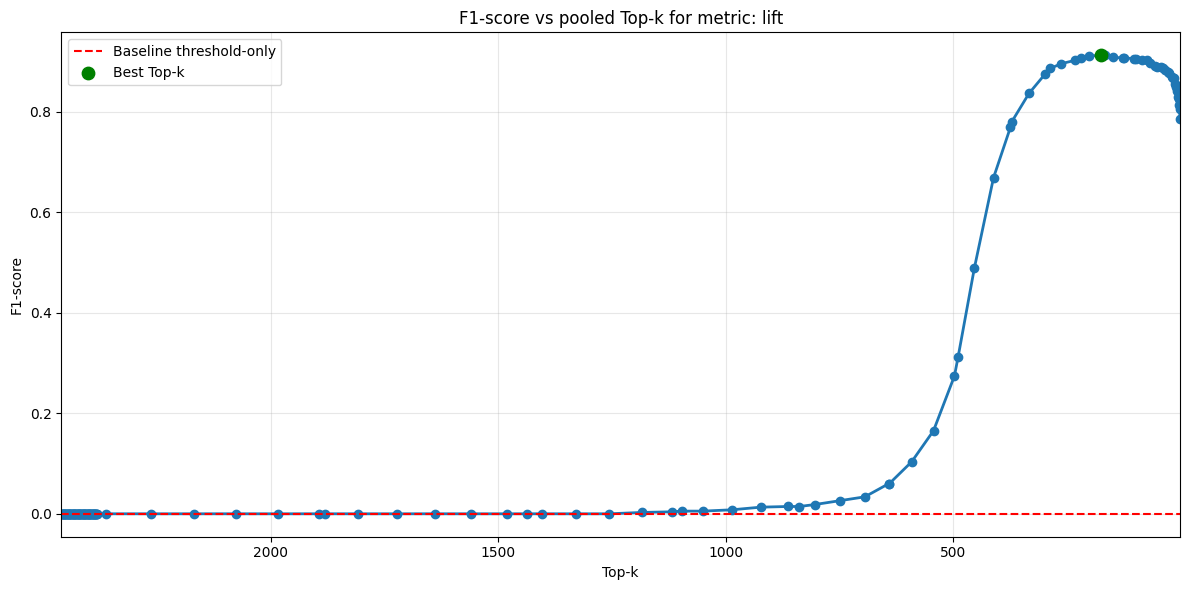

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\lift_topk_f1.png
Best k for lift: 174
Best F1-score: 0.911984
Average classifiers kept: 174.00

=== balanced_precision_proxy ===


Caching balanced_precision_proxy:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating balanced_precision_proxy:   0%|          | 0/153 [00:00<?, ?it/s]

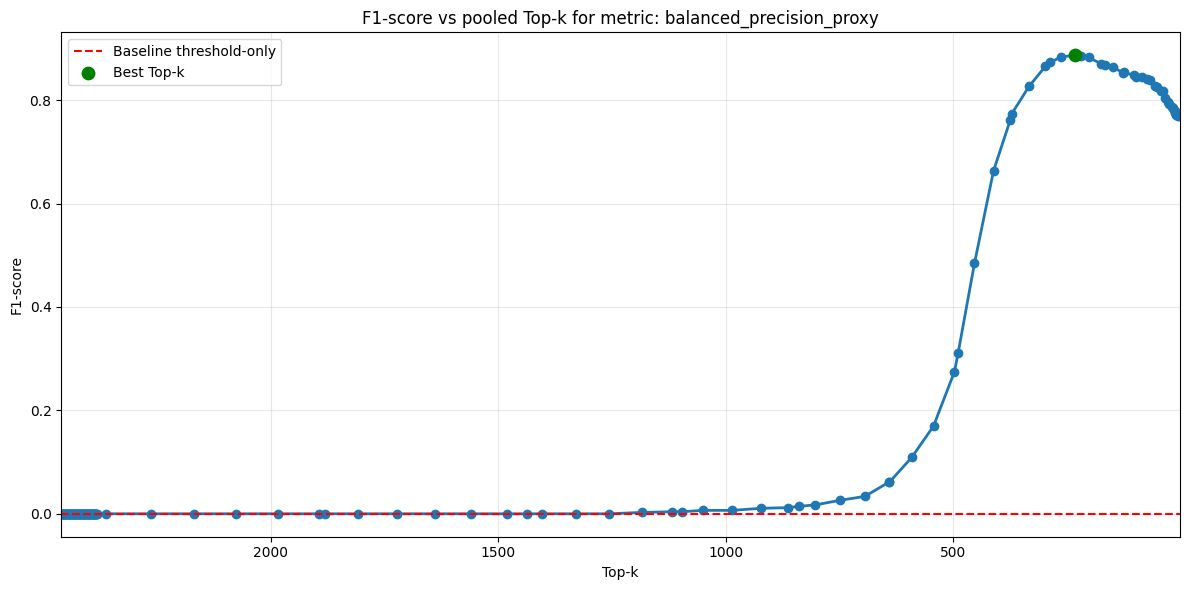

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\balanced_precision_proxy_topk_f1.png
Best k for balanced_precision_proxy: 232
Best F1-score: 0.886662
Average classifiers kept: 232.00

=== youdens_j ===


Caching youdens_j:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating youdens_j:   0%|          | 0/153 [00:00<?, ?it/s]

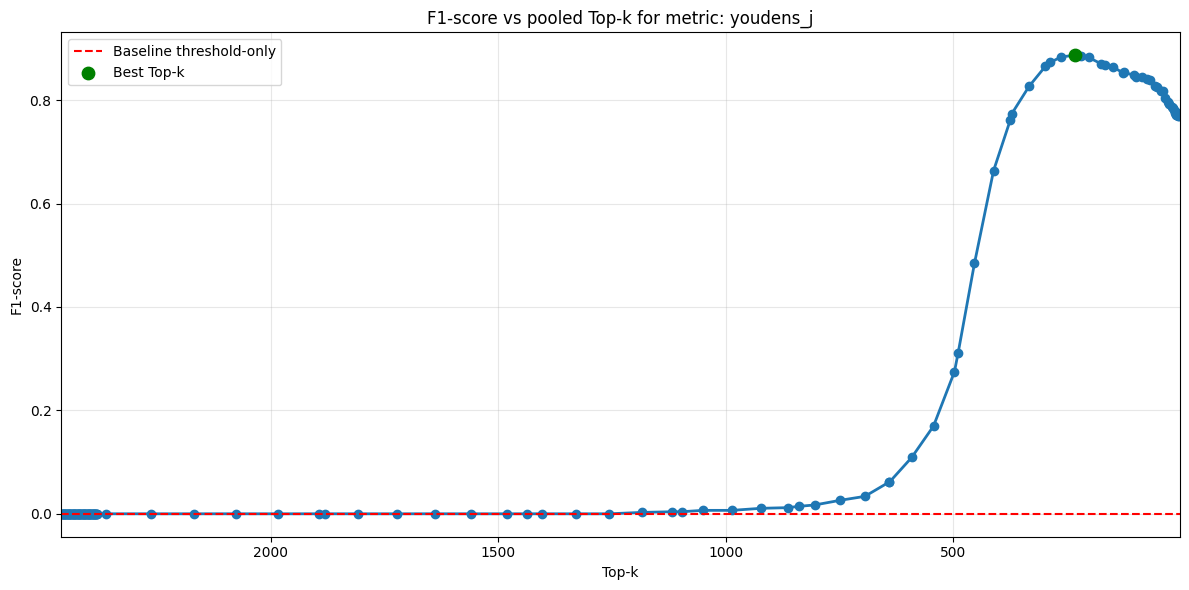

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\youdens_j_topk_f1.png
Best k for youdens_j: 232
Best F1-score: 0.886662
Average classifiers kept: 232.00

=== matthews_correlation ===


Caching matthews_correlation:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating matthews_correlation:   0%|          | 0/153 [00:00<?, ?it/s]

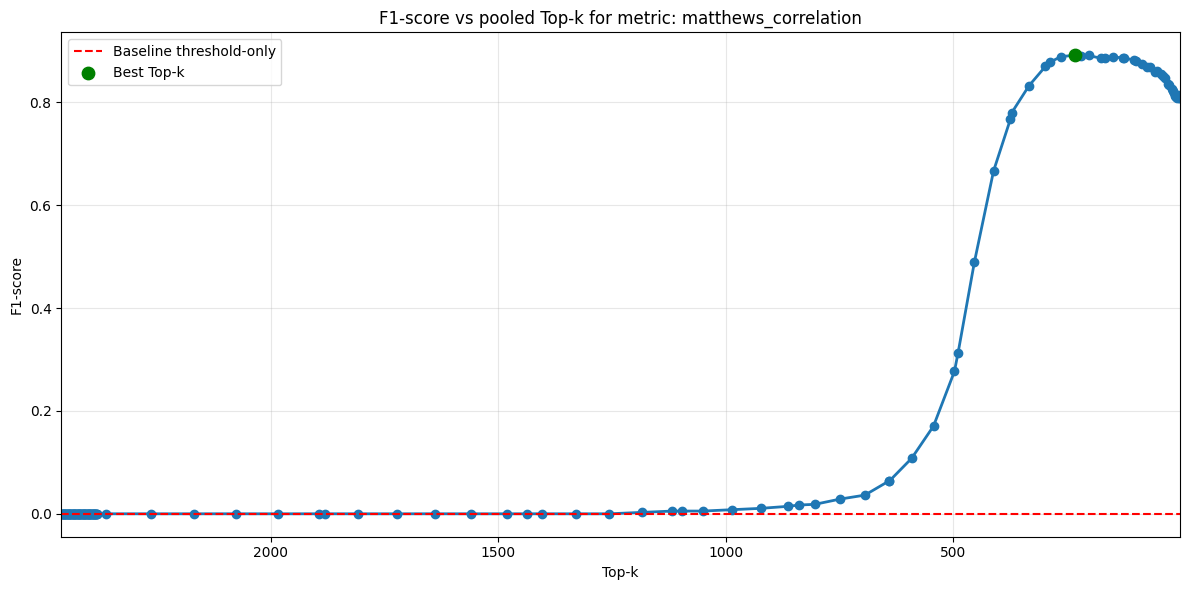

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\matthews_correlation_topk_f1.png
Best k for matthews_correlation: 232
Best F1-score: 0.891799
Average classifiers kept: 232.00

=== information_gain ===


Caching information_gain:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating information_gain:   0%|          | 0/153 [00:00<?, ?it/s]

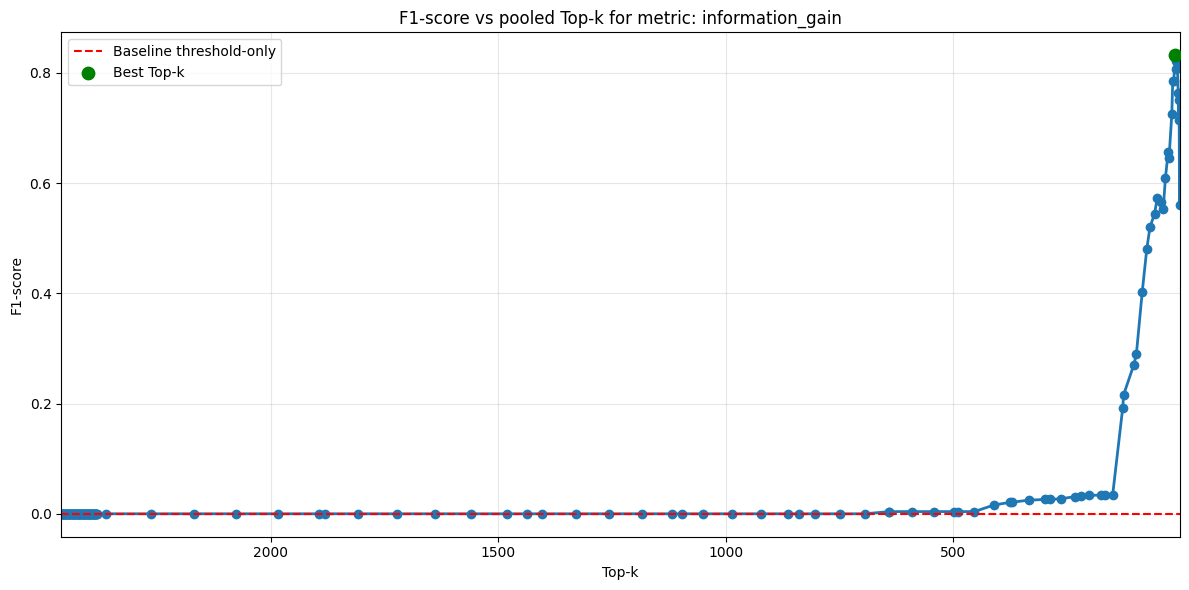

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\information_gain_topk_f1.png
Best k for information_gain: 11
Best F1-score: 0.832091
Average classifiers kept: 11.00

=== gini_gain ===


Caching gini_gain:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating gini_gain:   0%|          | 0/153 [00:00<?, ?it/s]

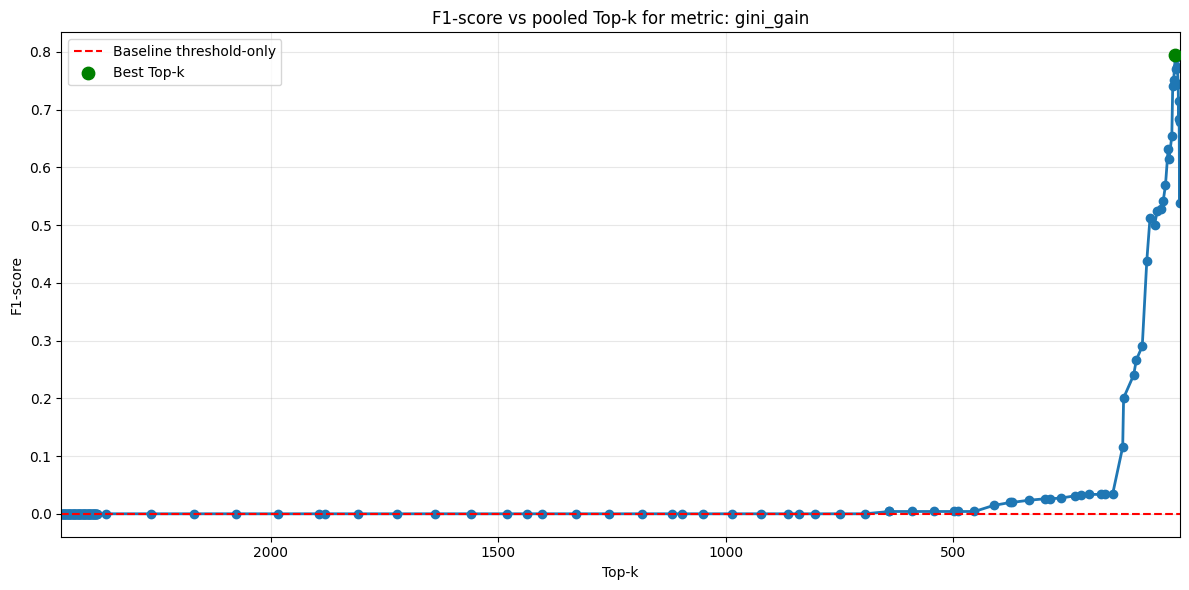

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\gini_gain_topk_f1.png
Best k for gini_gain: 11
Best F1-score: 0.794178
Average classifiers kept: 11.00

=== log_odds_ratio ===


Caching log_odds_ratio:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating log_odds_ratio:   0%|          | 0/153 [00:00<?, ?it/s]

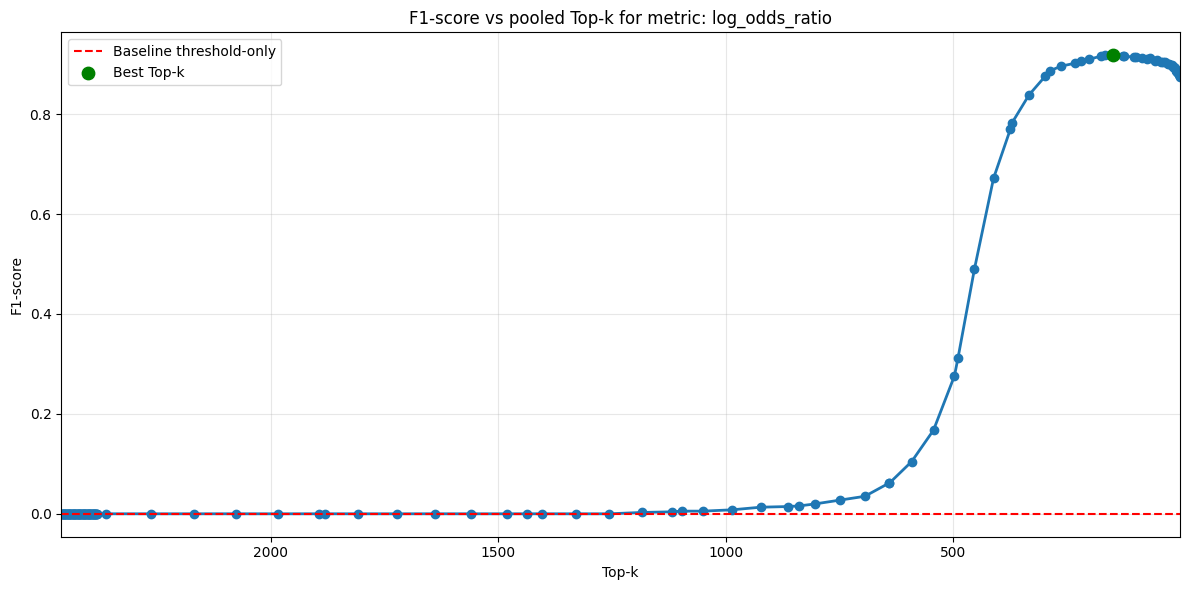

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\log_odds_ratio_topk_f1.png
Best k for log_odds_ratio: 149
Best F1-score: 0.917821
Average classifiers kept: 149.00

=== chi_squared ===


Caching chi_squared:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating chi_squared:   0%|          | 0/153 [00:00<?, ?it/s]

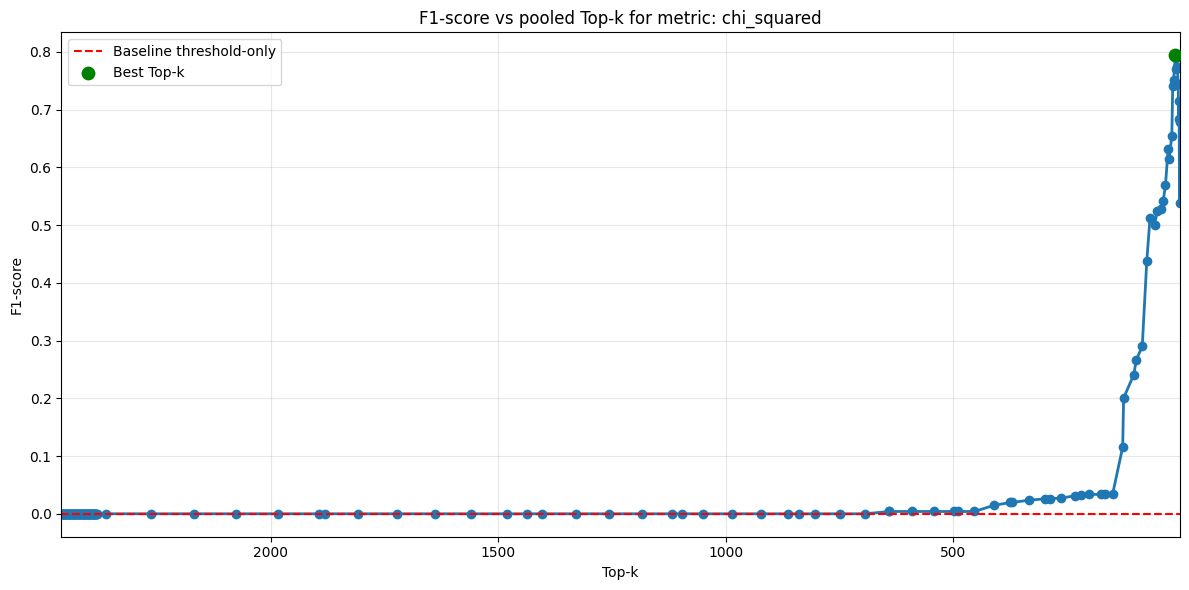

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\chi_squared_topk_f1.png
Best k for chi_squared: 11
Best F1-score: 0.794178
Average classifiers kept: 11.00

=== g_test ===


Caching g_test:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating g_test:   0%|          | 0/153 [00:00<?, ?it/s]

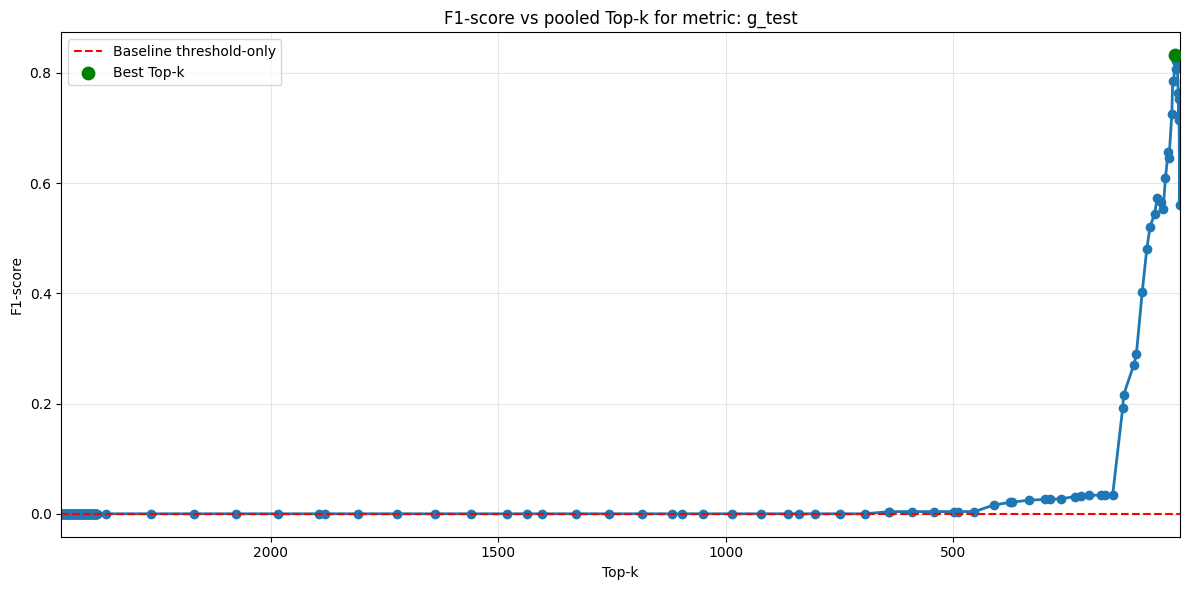

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\g_test_topk_f1.png
Best k for g_test: 11
Best F1-score: 0.832091
Average classifiers kept: 11.00

=== query_weighted_precision ===


Caching query_weighted_precision:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating query_weighted_precision:   0%|          | 0/153 [00:00<?, ?it/s]

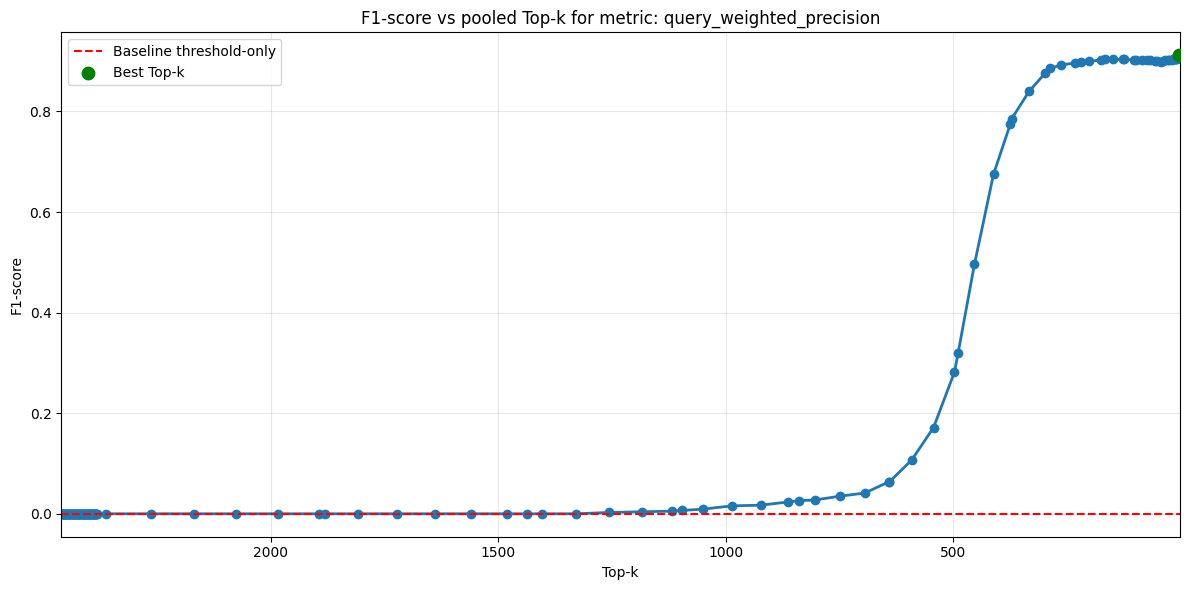

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\query_weighted_precision_topk_f1.png
Best k for query_weighted_precision: 3
Best F1-score: 0.911828
Average classifiers kept: 3.00

=== query_weighted_wracc ===


Caching query_weighted_wracc:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating query_weighted_wracc:   0%|          | 0/153 [00:00<?, ?it/s]

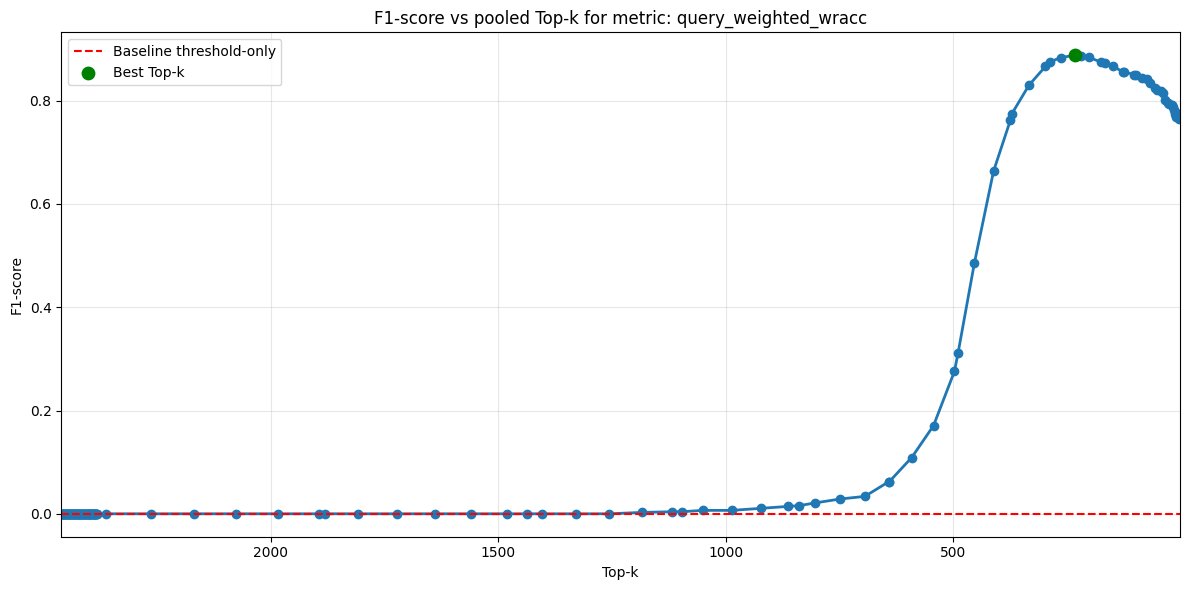

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\query_weighted_wracc_topk_f1.png
Best k for query_weighted_wracc: 232
Best F1-score: 0.887850
Average classifiers kept: 232.00

=== stability ===


Caching stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/153 [00:00<?, ?it/s]

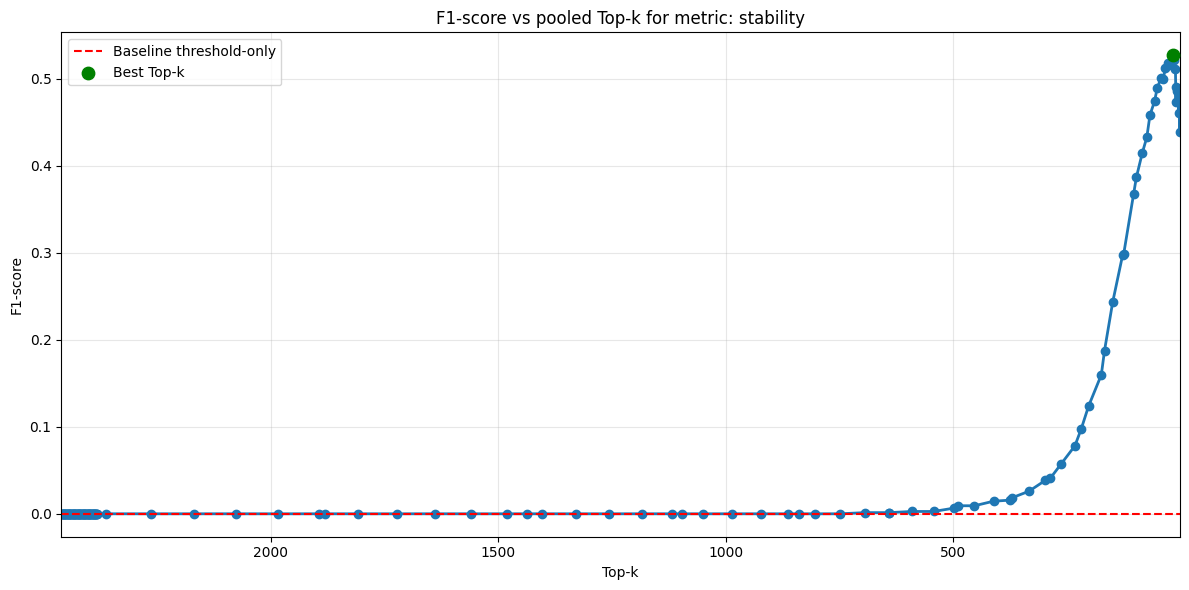

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\stability_topk_f1.png
Best k for stability: 17
Best F1-score: 0.526731
Average classifiers kept: 17.00

=== delta_stability ===


Caching delta_stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/153 [00:00<?, ?it/s]

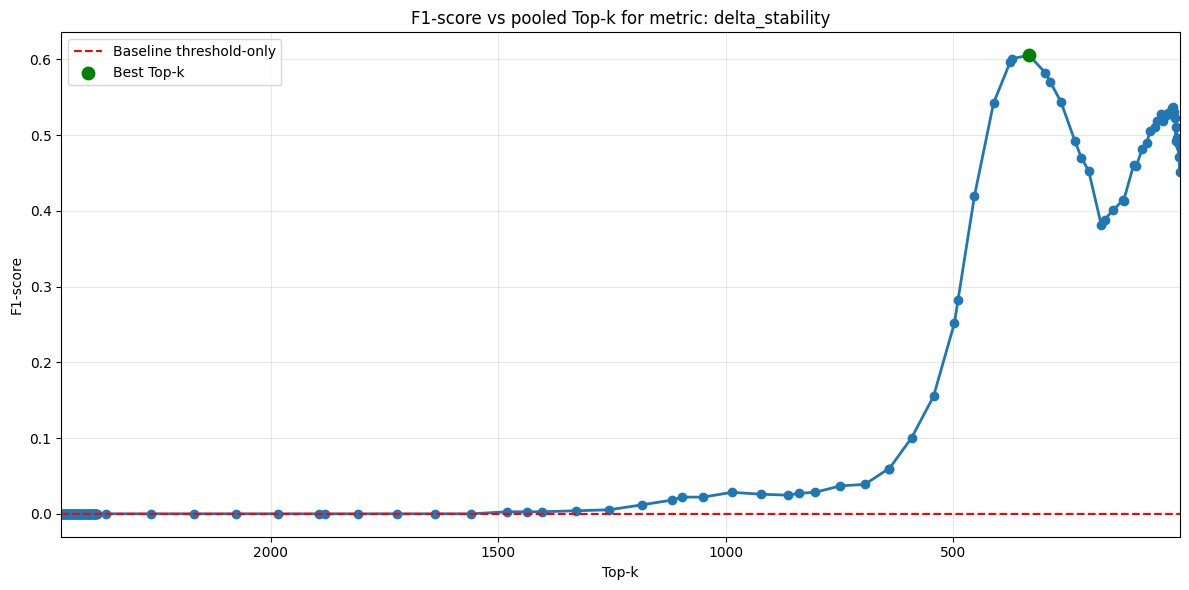

Saved plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\delta_stability_topk_f1.png
Best k for delta_stability: 333
Best F1-score: 0.605499
Average classifiers kept: 333.00


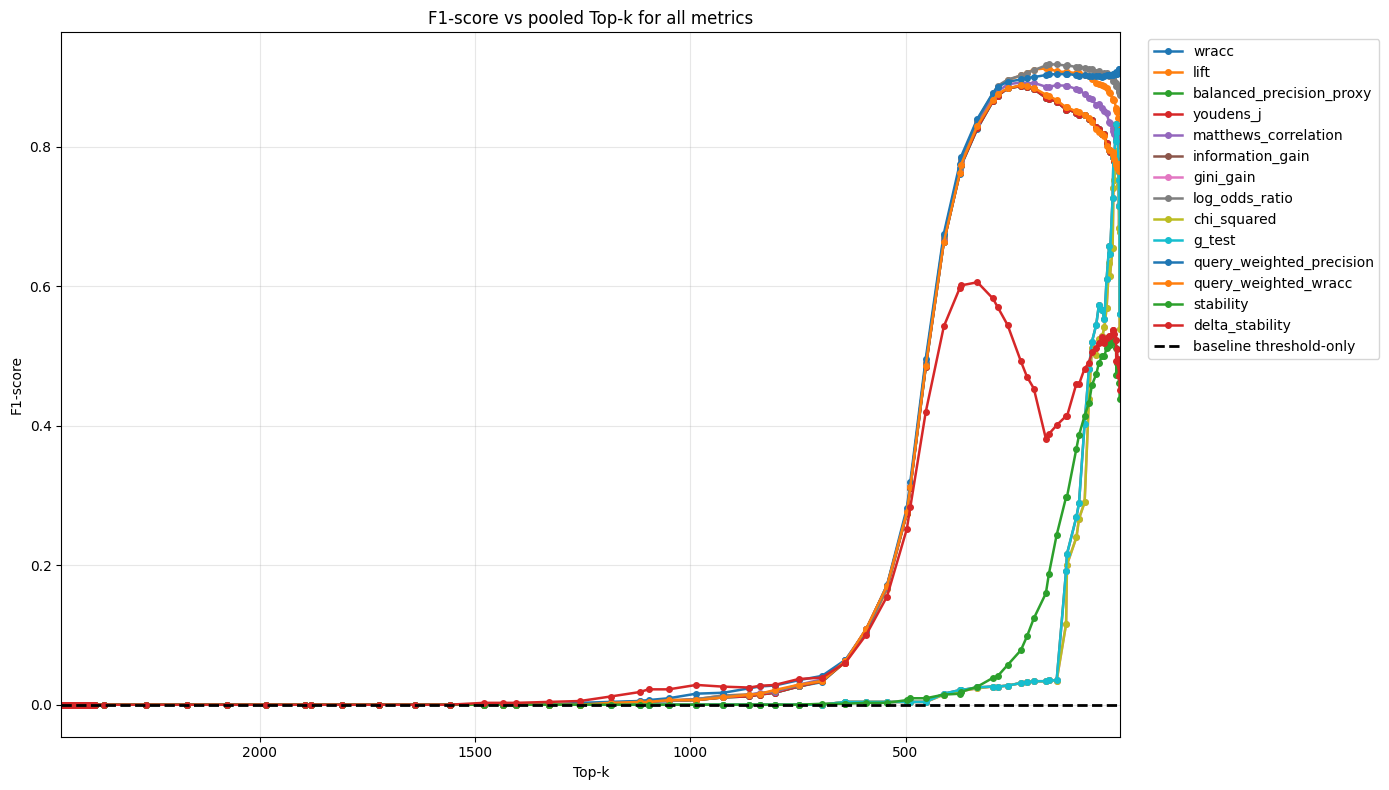


Saved combined plot to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\all_metrics_topk_f1.png
Saved summary CSV to: D:\OSDA-LazyFCA\experiments\generated_plots\taxi_topk_ranking_raw\topk_summary.csv


,metric,best_k,best_f1,avg_classifiers_kept
7,log_odds_ratio,149,0.917821,149.0
1,lift,174,0.911984,174.0
10,query_weighted_precision,3,0.911828,3.0
4,matthews_correlation,232,0.891799,232.0
11,query_weighted_wracc,232,0.887850,232.0
0,wracc,232,0.886662,232.0
2,balanced_precision_proxy,232,0.886662,232.0
3,youdens_j,232,0.886662,232.0
5,information_gain,11,0.832091,11.0
9,g_test,11,0.832091,11.0


In [14]:
metrics_to_plot = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

all_results = {}
summary_rows = []

for metric_name in metrics_to_plot:
    print(f"\n=== {metric_name} ===")
    results = plot_metric_topk(metric_name, k_values)
    all_results[metric_name] = results.copy()

    best_idx = results["F1-score"].idxmax()
    best_row = results.loc[best_idx]

    summary_rows.append({
        "metric": metric_name,
        "best_k": int(best_row["k"]),
        "best_f1": float(best_row["F1-score"]),
        "avg_classifiers_kept": float(best_row["Average classifiers kept"]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by="best_f1", ascending=False)
summary_df.to_csv(PLOTS_DIR / "topk_summary.csv", index=False)

# Combined plot with all metrics together
plt.figure(figsize=(14, 8))
for metric_name, results in all_results.items():
    plt.plot(results["k"], results["F1-score"], marker="o", linewidth=1.8, markersize=4, label=metric_name)

plt.axhline(
    baseline_metrics["F1-score"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="baseline threshold-only"
)

plt.xlabel("Top-k")
plt.ylabel("F1-score")
plt.title("F1-score vs pooled Top-k for all metrics")
plt.xlim(max(k_values), min(k_values))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

combined_plot_path = PLOTS_DIR / "all_metrics_topk_f1.png"
plt.savefig(combined_plot_path, dpi=220, bbox_inches="tight")
plt.show()

print(f"\nSaved combined plot to: {combined_plot_path}")
print(f"Saved summary CSV to: {PLOTS_DIR / 'topk_summary.csv'}")

summary_df


In [15]:
metric_name = "query_weighted_precision"
k_value = 20

results = evaluate_metric_topk(metric_name, np.array([k_value]))
row = results.iloc[0]

print(f"Metric: {metric_name}")
print(f"Top-k: {int(row['k'])}")
print(f"F1-score: {row['F1-score']:.6f}")
print(f"Accuracy: {row['Accuracy']:.6f}")
print(f"Precision: {row['Precision']:.6f}")
print(f"Recall: {row['Recall']:.6f}")
print(f"AUC-ROC: {row['AUC-ROC']:.6f}")
print(f"Average classifiers kept: {row['Average classifiers kept']:.2f}")


Caching query_weighted_precision:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating query_weighted_precision:   0%|          | 0/1 [00:00<?, ?it/s]

Metric: query_weighted_precision
Top-k: 20
F1-score: 0.903482
Accuracy: 0.894667
Precision: 0.833709
Recall: 0.986000
AUC-ROC: 0.940543
Average classifiers kept: 20.00


In [16]:
def rank_metrics_by_f1_retention(
    metrics_to_check,
    allowed_drop_percent=5.0,
    k_values=k_values,
    baseline_f1=None,
    explanations=explanations,
    y_true=y_test,
    pos_weight=1.0,
):
    """
    Rank metrics by how aggressively they can prune while keeping F1 within
    an allowed percentage drop from baseline.

    Rule:
    - Let baseline F1 be F_base.
    - Allowed minimum F1 is:
          F_min = F_base * (1 - allowed_drop_percent / 100)
    - We scan k_values in descending order (from large k to small k).
    - As soon as F1 drops below F_min, we stop.
    - The selected k is the last valid k before the break.

    Output:
    - A dataframe ordered best -> worst.
    - Best means smaller retained k first.
    - Ties are broken by higher retained F1.
    """

    if baseline_f1 is None:
        baseline_f1 = float(baseline_metrics["F1-score"])

    if allowed_drop_percent < 0:
        raise ValueError("allowed_drop_percent must be non-negative")

    f1_threshold = baseline_f1 * (1.0 - allowed_drop_percent / 100.0)

    rows = []

    for metric_name in metrics_to_check:
        results = evaluate_metric_topk(
            metric_name=metric_name,
            k_values=k_values,
            explanations=explanations,
            y_true=y_true,
            pos_weight=pos_weight,
        ).sort_values("k", ascending=False).reset_index(drop=True)

        last_valid_row = None
        broke = False

        for _, row in results.iterrows():
            if row["F1-score"] >= f1_threshold:
                last_valid_row = row
            else:
                broke = True
                break

        if last_valid_row is None:
            rows.append({
                "metric": metric_name,
                "selected_k": np.nan,
                "selected_f1": np.nan,
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": np.nan,
                "status": "never_satisfies_rule",
            })
        else:
            rows.append({
                "metric": metric_name,
                "selected_k": int(last_valid_row["k"]),
                "selected_f1": float(last_valid_row["F1-score"]),
                "baseline_f1": baseline_f1,
                "f1_threshold": f1_threshold,
                "avg_classifiers_kept": float(last_valid_row["Average classifiers kept"]),
                "status": "break_found" if broke else "all_k_valid",
            })

    summary = pd.DataFrame(rows)

    # Best -> worst:
    # 1) metrics that satisfy the rule
    # 2) among them, smaller selected_k is better
    # 3) if tied, higher F1 is better
    # 4) metrics that never satisfy the rule go last
    summary["valid"] = summary["selected_k"].notna()

    summary = summary.sort_values(
        by=["valid", "selected_k", "selected_f1"],
        ascending=[False, True, False],
        na_position="last",
    ).reset_index(drop=True)

    return summary.drop(columns=["valid"])


In [17]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=1.0,
)


Caching wracc:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/153 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/153 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/153 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/153 [00:00<?, ?it/s]

,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,query_weighted_precision,1,0.911221,0.0,0.0,1.0,all_k_valid
1,log_odds_ratio,1,0.883833,0.0,0.0,1.0,all_k_valid
2,matthews_correlation,1,0.809280,0.0,0.0,1.0,all_k_valid
3,lift,1,0.784838,0.0,0.0,1.0,all_k_valid
4,query_weighted_wracc,1,0.770812,0.0,0.0,1.0,all_k_valid
5,wracc,1,0.770614,0.0,0.0,1.0,all_k_valid
6,balanced_precision_proxy,1,0.770614,0.0,0.0,1.0,all_k_valid
7,youdens_j,1,0.770614,0.0,0.0,1.0,all_k_valid
8,information_gain,1,0.763264,0.0,0.0,1.0,all_k_valid
9,g_test,1,0.763264,0.0,0.0,1.0,all_k_valid


In [18]:
metrics_to_check = [
    "wracc",
    "lift",
    "balanced_precision_proxy",
    "youdens_j",
    "matthews_correlation",
    "information_gain",
    "gini_gain",
    "log_odds_ratio",
    "chi_squared",
    "g_test",
    "query_weighted_precision",
    "query_weighted_wracc",
    "stability",
    "delta_stability",
]

rank_metrics_by_f1_retention(
    metrics_to_check=metrics_to_check,
    allowed_drop_percent=1.0,
)


Caching wracc:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating wracc:   0%|          | 0/153 [00:00<?, ?it/s]

Caching lift:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating lift:   0%|          | 0/153 [00:00<?, ?it/s]

Caching balanced_precision_proxy:   0%|          | 0/3000 [00:00<?, ?it/s]

...

Caching stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating stability:   0%|          | 0/153 [00:00<?, ?it/s]

Caching delta_stability:   0%|          | 0/3000 [00:00<?, ?it/s]

Evaluating delta_stability:   0%|          | 0/153 [00:00<?, ?it/s]

,metric,selected_k,selected_f1,baseline_f1,f1_threshold,avg_classifiers_kept,status
0,query_weighted_precision,1,0.911221,0.0,0.0,1.0,all_k_valid
1,log_odds_ratio,1,0.883833,0.0,0.0,1.0,all_k_valid
2,matthews_correlation,1,0.809280,0.0,0.0,1.0,all_k_valid
3,lift,1,0.784838,0.0,0.0,1.0,all_k_valid
4,query_weighted_wracc,1,0.770812,0.0,0.0,1.0,all_k_valid
5,wracc,1,0.770614,0.0,0.0,1.0,all_k_valid
6,balanced_precision_proxy,1,0.770614,0.0,0.0,1.0,all_k_valid
7,youdens_j,1,0.770614,0.0,0.0,1.0,all_k_valid
8,information_gain,1,0.763264,0.0,0.0,1.0,all_k_valid
9,g_test,1,0.763264,0.0,0.0,1.0,all_k_valid


## Try results

In [21]:
classifier = LazyFCA(rank_by = 'query_weighted_precision', top_k = 3, minimize_policy=LazyFCA.MinimizePolicy.BEFORE_FILTER)
classifier.fit(X_train, y_train)

LazyFCA
  Status       : fitted
  Dataset      : 27000 samples (pos=13500, neg=13500)
  Features     : 0 binary, 25 numeric

  Filtering thresholds
  ------------------------------------
  pos_params    : (none)
  neg_params    : (none)
  pos_weight    : 1.0

  Ranking & top-k
  ------------------------------------
  pos_rank_by   : —
  neg_rank_by   : —
  rank_by       : query_weighted_precision
  pos_top_k     : —
  neg_top_k     : —
  top_k         : 3
  minimize_policy: MinimizePolicy.BEFORE_FILTER

In [22]:
explanations = classifier.explain(X_test)
print(len(explanations))

y_pred = classifier.classify_explanations(explanations, trust = True)
metrics = estimate_quality(y_pred, y_test)
metrics




























































































































































































100%|██████████| 3000/3000 [32:02<00:00,  1.56it/s]


3000


{'Accuracy': 0.9043333333333333,
 'Precision': 0.8455840455840455,
 'Recall': 0.9893333333333333,
 'AUC-ROC': 0.9237624444444446,
 'F1-score': 0.9118279569892473,
 'True Positive': 1484,
 'True Negative': 1229,
 'False Positive': 271,
 'False Negative': 16,
 'True Negative Rate (Specificity)': 0.8193333333333334,
 'Negative Predictive Value': 0.98714859437751,
 'False Positive Rate': 0.18066666666666667,
 'False Discovery Rate': 0.1544159544159544}

In [23]:
scores = pandas.concat(map(lambda explanation: explanation.display(), explanations), axis = 0).drop_duplicates()
scores

,Hypothesis,Type,Supporters,Opposers,True positive,False positive,True negative,False negative,Supporters to opposers ratio,Support,...,Query binary similarity,Query numeric similarity,Query similarity,Query weighted precision,Query weighted precision log TP,Query weighted precision sqrt TP,Query weighted WRAcc,Stability,Robustness,Delta stability
0,"[2.0, 4.0]; [4.07, 5.75]; [26.1, 27.5]; [1.0, ...",POSITIVE,13500,13500,54,2,13498,13446,27.000000,0.004000,...,1.0,0.985793,0.985793,0.950586,3.809315,6.985352,0.000949,0.492067,0.492067,1.0
1,"[2.0, 3.0]; [4.07, 6.13]; [26.8, 27.5]; [1.0, ...",POSITIVE,13500,13500,38,0,13500,13462,inf,0.002815,...,1.0,0.949101,0.949101,0.949101,3.477090,5.850651,0.000668,0.190653,0.190653,1.0
2,"[0.0, 2.0]; [4.07, 5.55]; [26.1, 27.5]; [1.0, ...",POSITIVE,13500,13500,124,5,13495,13376,24.800000,0.009185,...,1.0,0.985887,0.985887,0.947675,4.575671,10.552859,0.002173,0.218750,0.218750,1.0
0,"[1.0, 3.0]; [0.03, 1.65]; [3.0, 10.7]; [0.0, 5...",NEGATIVE,13500,13500,1497,0,13500,12003,inf,0.110889,...,1.0,0.974654,0.974654,0.974654,7.126559,37.710417,0.027020,0.249876,0.249876,1.0
1,"[3.0, 6.0]; [1.65, 1.81]; [10.7, 12.1]; [0.0, ...",NEGATIVE,13500,13500,12,0,13500,13488,inf,0.000889,...,1.0,0.974440,0.974440,0.974440,2.499388,3.375558,0.000217,0.046034,0.046034,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,"[1.0, 4.0]; [3.33, 3.77]; [17.7, 19.1]; [1.0, ...",POSITIVE,13500,13500,107,7,13493,13393,15.285714,0.007926,...,1.0,0.979713,0.979713,0.919555,4.305477,9.511950,0.001814,0.351562,0.351562,1.0
2,"[1.0, 1.0]; [3.33, 3.51]; [14.9, 19.1]; [1.0, ...",POSITIVE,13500,13500,56,5,13495,13444,11.200000,0.004148,...,1.0,0.999677,0.999677,0.917736,3.710456,6.867711,0.000944,0.669901,0.669901,3.0
0,"[2.0, 3.0]; [4.12, 4.24]; [21.9, 26.1]; [1.0, ...",POSITIVE,13500,13500,9,0,13500,13491,inf,0.000667,...,1.0,0.989891,0.989891,0.989891,2.279308,2.969672,0.000165,0.066565,0.066565,1.0
1,"[2.0, 5.0]; [3.92, 4.12]; [26.1, 26.8]; [1.0, ...",POSITIVE,13500,13500,2,0,13500,13498,inf,0.000148,...,1.0,0.979866,0.979866,0.979866,1.076493,1.385739,0.000036,0.000042,0.000042,1.0


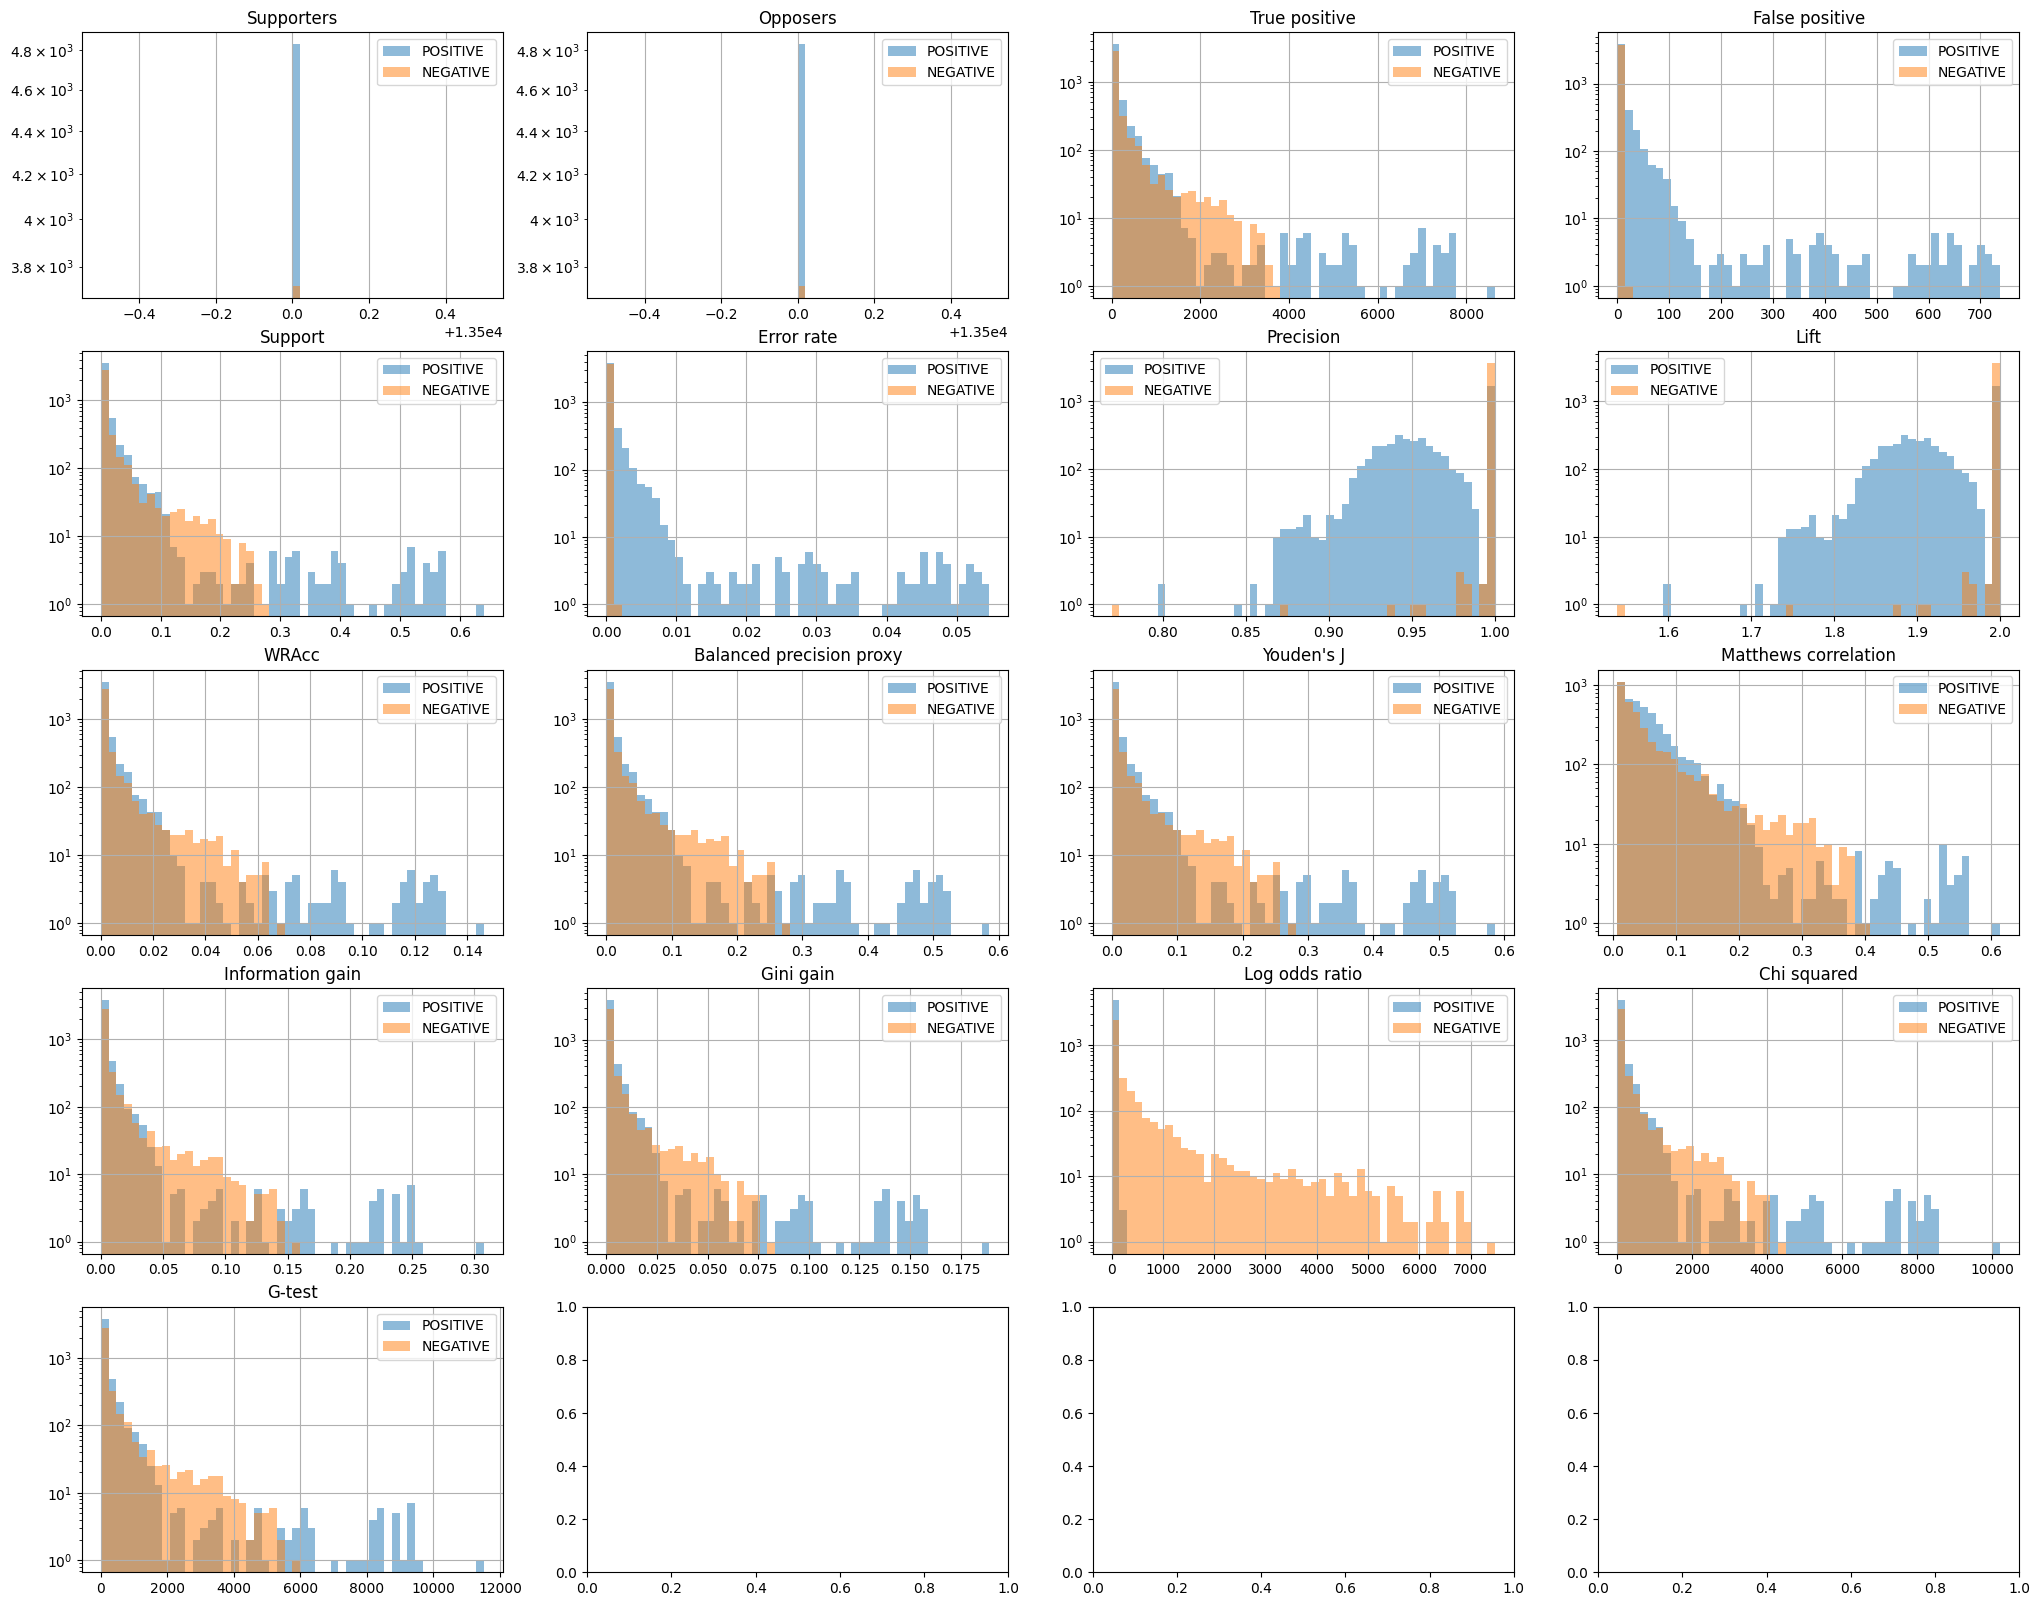

In [24]:
COLUMNS = [
    'Supporters', 'Opposers', 'True positive', 'False positive',
    'Support', 'Error rate', 'Precision', 'Lift', 'WRAcc',
    'Balanced precision proxy', 'Youden\'s J', 'Matthews correlation',
    "Information gain", "Gini gain", "Log odds ratio", "Chi squared", "G-test"
]
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    range = (scores[column].min(), scores[column].max())
    scores[scores["Type"] == "POSITIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'POSITIVE')
    scores[scores["Type"] == "NEGATIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'NEGATIVE')
    ax.legend()
    ax.set_yscale('log')